### Group ID: 25
### Group Members Name with Student ID:
| Name                             | ID              | Contribution   |
|----------------------------------|-----------------|----------------|
| Prasath J                        | 2024AA05323     | 100%           |
| Vishwanath Rajakumar             | 2024AA05309     | 100%           |
| Adi Sathwik                      | 2024AB05213     | 100%           |
| Jagadi Shruti Chanabasappa       | 2024AA05181     | 100%           |
| Kannan S                         | 2024AA05035     | 100%           |


# Assignment Solution: Heart Disease Prediction - Exploratory Data Analysis (EDA)

## Problem Statement
Perform comprehensive exploratory data analysis on the UCI Heart Disease dataset to understand:
- Dataset characteristics and structure
- Feature distributions and patterns
- Feature correlations and relationships
- Class balance and target variable distribution
- Data quality issues (missing values, outliers)
- Key insights for model development

## Objective
Conduct professional EDA with visualizations including:
- **Histograms** - Feature distributions
- **Correlation Heatmaps** - Feature relationships
- **Class Balance Analysis** - Target variable distribution
- **Statistical Summaries** - Dataset overview
- **Feature Analysis** - Comparison by target class


## 1. Package Installation and Imports

### 1.1 Package Installation (Run if dependencies are missing)

If you encounter import errors, run the cell below to install required packages:
- **pandas** - Data manipulation and analysis
- **numpy** - Numerical computations
- **matplotlib** - Visualization and plotting
- **seaborn** - Statistical data visualization
- **scikit-learn** - Machine learning utilities (for data loading)


In [54]:
# Run this cell to install required packages into the notebook kernel
%pip install pandas numpy matplotlib seaborn scikit-learn -q


Note: you may need to restart the kernel to use updated packages.


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import warnings

warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Determine project root directory
current_dir = os.getcwd()
if os.path.basename(current_dir) == 'notebooks':
    project_root = os.path.dirname(current_dir)
else:
    project_root = current_dir

# Add src to path for importing preprocessing pipeline
sys.path.append(project_root)

# Create screenshots directory if it doesn't exist
screenshots_dir = os.path.join(project_root, 'screenshots')
os.makedirs(screenshots_dir, exist_ok=True)


In [56]:
# 1.2 Environment Check

import sys
import matplotlib

# Display environment information
env_info = {
    "Python Version": sys.version.split()[0],
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "matplotlib": matplotlib.__version__,
    "seaborn": sns.__version__
}

pd.DataFrame([env_info])


,Python Version,pandas,numpy,matplotlib,seaborn
0,3.12.2,2.2.3,1.26.4,3.10.0,0.13.2


## 2. Data Acquisition and Loading

### 2.1 Dataset Information

The UCI Heart Disease dataset contains medical records from multiple sources:
- **Cleveland** - 303 records
- **Hungarian** - 294 records  
- **Switzerland** - 123 records
- **Long Beach VA** - 200 records

**Note**: Data preprocessing (cleaning, handling missing values, encoding) is handled by the preprocessing pipeline in `src/data_processing/preprocess.py`. Here we load the cleaned data for EDA purposes.


In [57]:
# Load data using the preprocessing pipeline
from src.data_processing.preprocess import preprocess_pipeline

# Load and preprocess data
zip_path = os.path.join(project_root, "heart_disease_dataset.zip")
data_dir = os.path.join(project_root, "data")

X_train, X_test, y_train, y_test, scaler, X_train_scaled, X_test_scaled = preprocess_pipeline(
    zip_path, data_dir
)

# Combine train and test for full dataset EDA
X_full = pd.concat([X_train, X_test], ignore_index=True)
y_full = pd.concat([y_train, y_test], ignore_index=True)
df = pd.concat([X_full, y_full], axis=1)

# Display dataset summary
dataset_summary = {
    "Total Samples": [df.shape[0]],
    "Total Features": [X_full.shape[1]],
    "Target Variable": ["Binary (0 = No Disease, 1 = Disease)"]
}
pd.DataFrame(dataset_summary)


Data extracted to /Users/kannans/dev/Group_25_MLOps/data
Loaded 28858 rows from 10 files
Cleaned data: 28858 rows, 15 columns
Train set: 23086 samples
Test set: 5772 samples
Features scaled using StandardScaler


,Total Samples,Total Features,Target Variable
0,28858,13,"Binary (0 = No Disease, 1 = Disease)"


In [58]:
# Target variable distribution
target_dist = pd.DataFrame({
    'Class': ['No Disease (0)', 'Disease (1)'],
    'Count': [y_full.value_counts()[0], y_full.value_counts()[1]],
    'Percentage': [
        y_full.value_counts(normalize=True)[0] * 100,
        y_full.value_counts(normalize=True)[1] * 100
    ]
})
target_dist


,Class,Count,Percentage
0,No Disease (0),411,1.424215
1,Disease (1),28447,98.575785


## 3. Dataset Overview

### 3.1 Basic Dataset Information


In [59]:
# Basic dataset information
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()


Dataset Shape: 28858 rows × 14 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,54.0,1.0,4.0,130.0,223.0,0.0,0.0,140.0,0.0,0.5,2.0,0.0,6.0,1
1,54.0,1.0,4.0,130.0,223.0,0.0,0.0,140.0,0.0,0.5,2.0,0.0,6.0,1
2,54.0,1.0,4.0,130.0,223.0,0.0,0.0,140.0,0.0,0.5,2.0,0.0,6.0,1
3,54.0,1.0,4.0,130.0,223.0,0.0,0.0,140.0,0.0,0.5,2.0,0.0,6.0,1
4,54.0,1.0,4.0,130.0,223.0,0.0,0.0,140.0,0.0,0.5,2.0,0.0,6.0,1


In [60]:
# Statistical summary
df.describe()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,28858.000000,28858.000000,28858.000000,28858.000000,28858.000000,28858.000000,28858.000000,28858.000000,28858.000000,28858.000000,28858.000000,28858.000000,28858.000000,28858.000000
mean,53.999272,0.993277,3.976090,130.063622,222.263844,0.004782,0.019232,139.926433,0.011678,0.511262,1.995149,0.007242,5.986278,0.985758
std,2.270639,0.081717,0.212045,3.311366,19.877297,0.068988,0.178585,4.505605,0.107433,0.198754,0.095887,0.119123,0.259989,0.118490
min,3.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,1.000000,0.000000,3.000000,0.000000
25%,54.000000,1.000000,4.000000,130.000000,223.000000,0.000000,0.000000,140.000000,0.000000,0.500000,2.000000,0.000000,6.000000,1.000000
50%,54.000000,1.000000,4.000000,130.000000,223.000000,0.000000,0.000000,140.000000,0.000000,0.500000,2.000000,0.000000,6.000000,1.000000
75%,54.000000,1.000000,4.000000,130.000000,223.000000,0.000000,0.000000,140.000000,0.000000,0.500000,2.000000,0.000000,6.000000,1.000000
max,237.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


## 4. Feature Distributions (Histograms)

Visualize the distribution of each feature to understand data characteristics, identify outliers, and understand the shape of the data.


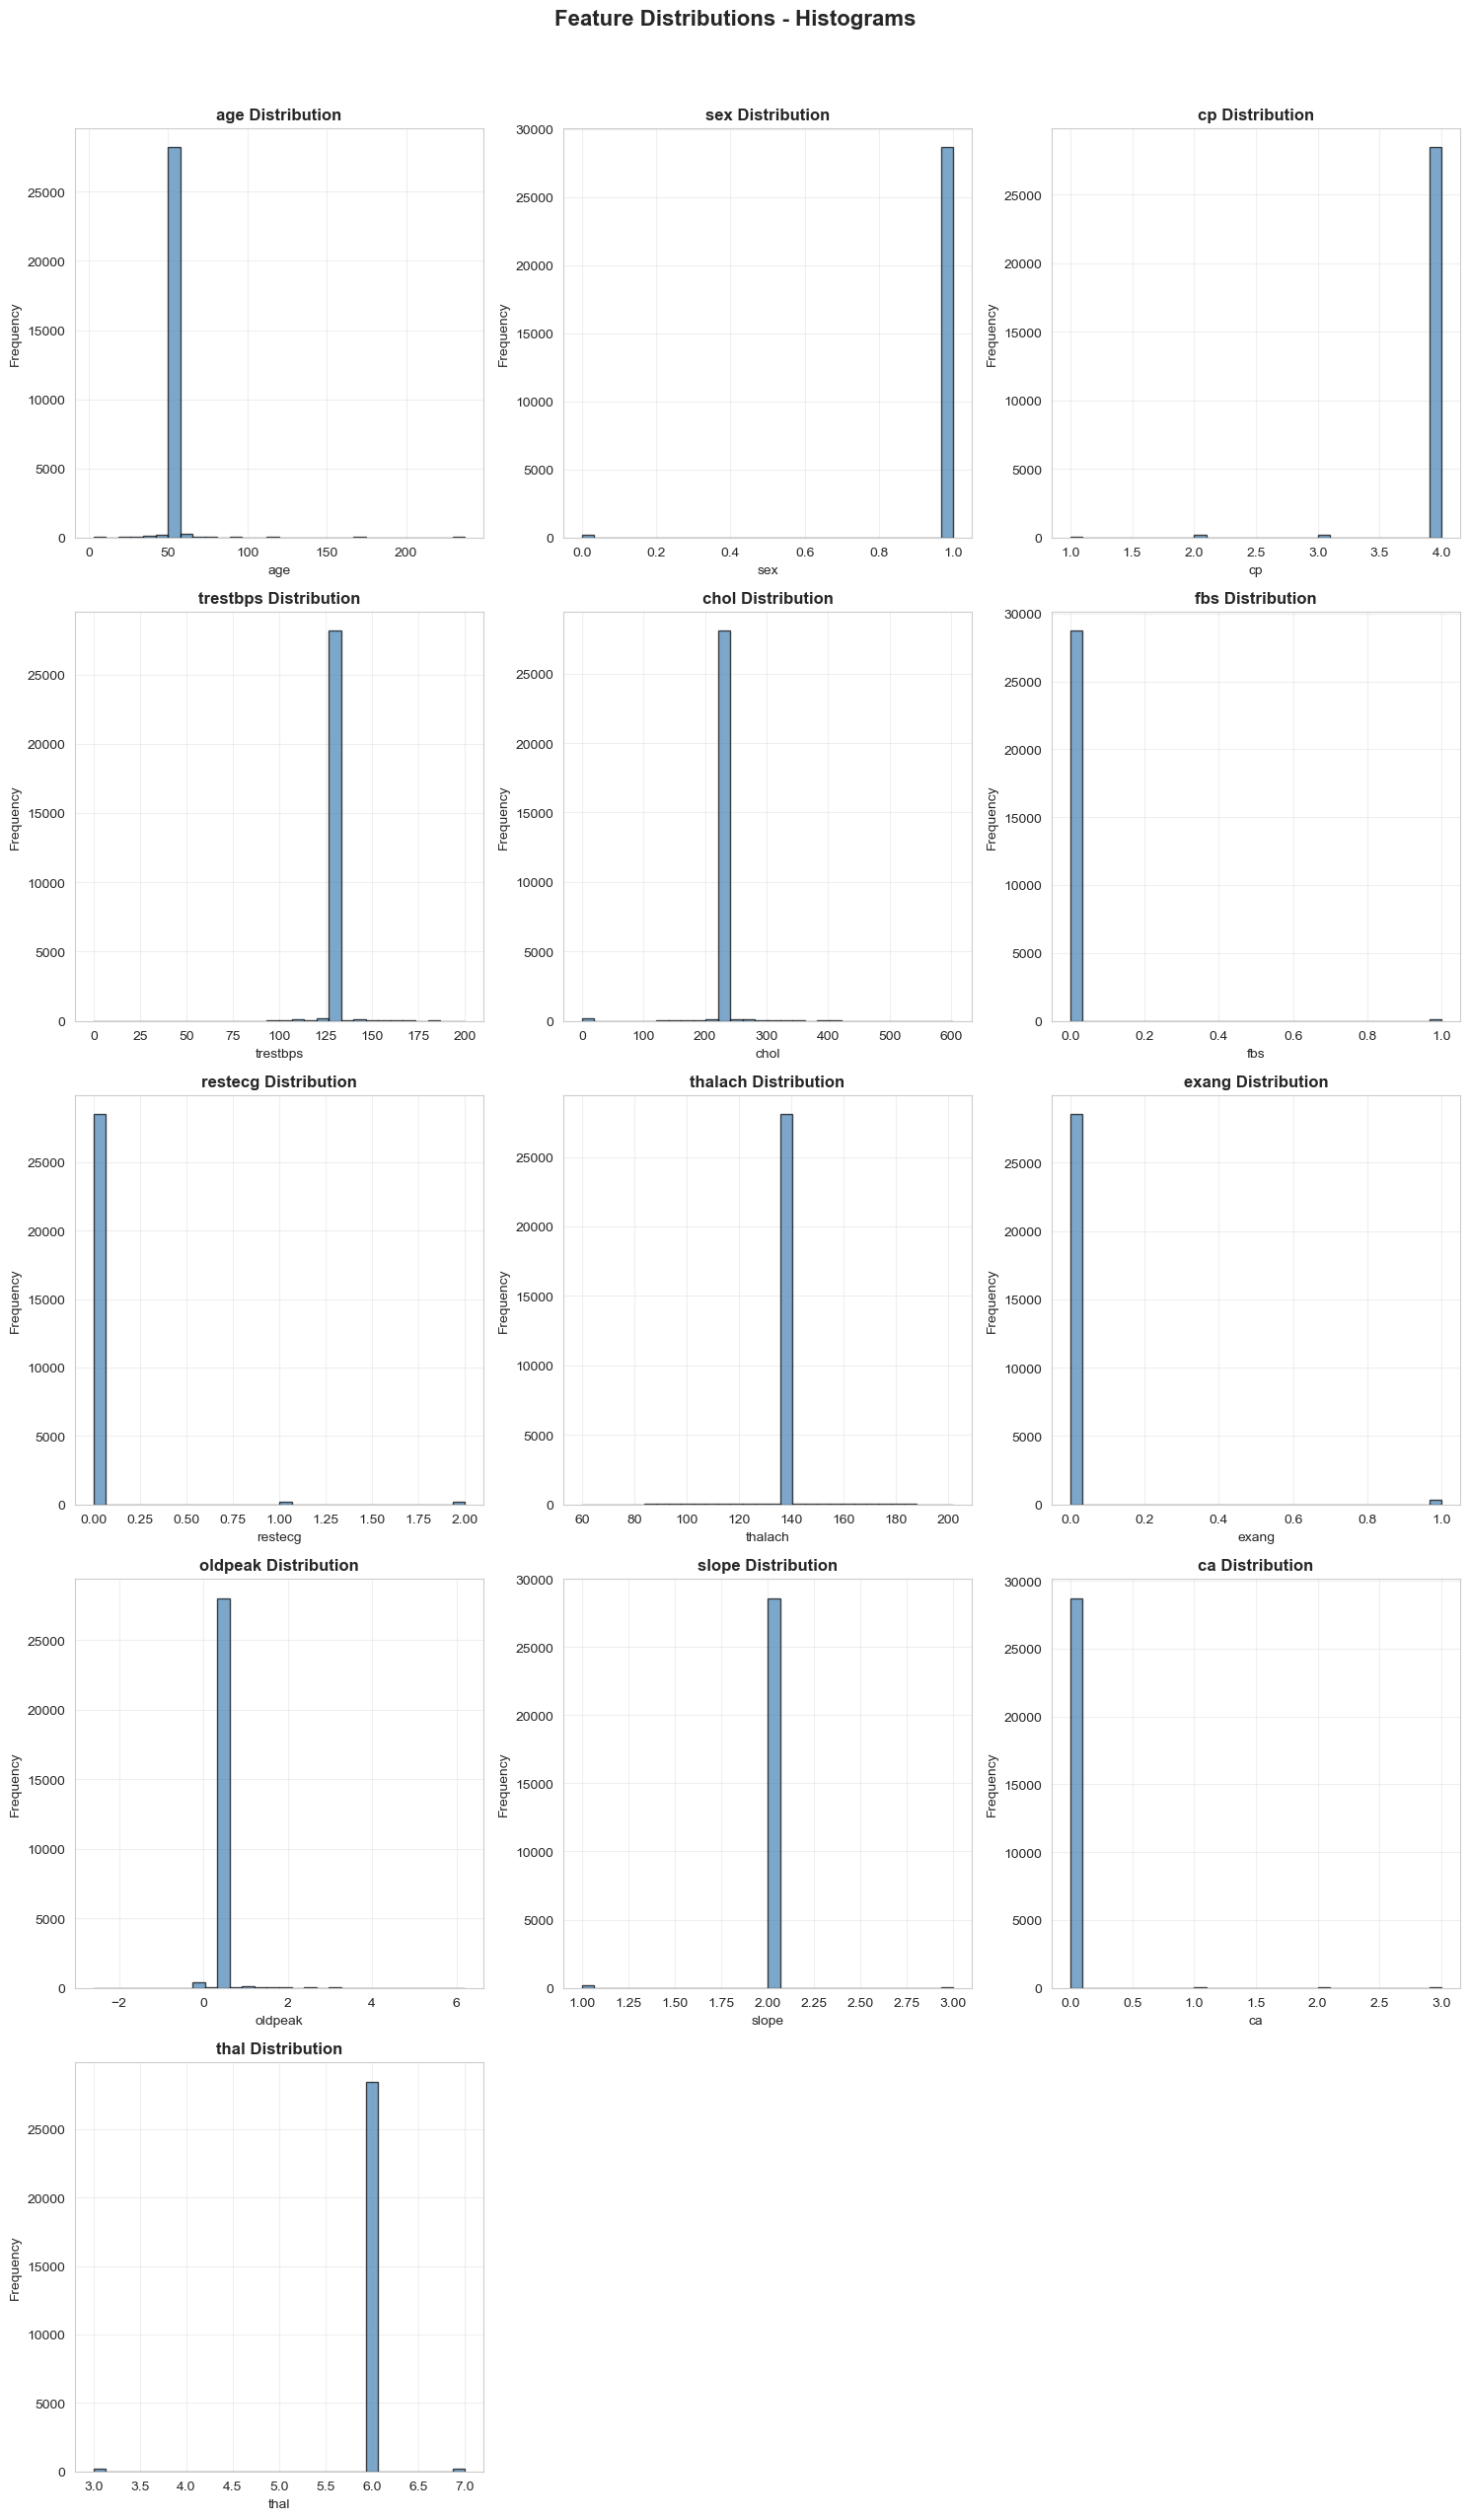

✓ Histograms saved to /Users/kannans/dev/Group_25_MLOps/screenshots/eda_histograms.png


In [61]:
# Plot histograms for all numerical features
feature_cols = X_full.columns.tolist()
n_features = len(feature_cols)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_features > 1 else [axes]

for idx, col in enumerate(feature_cols):
    axes[idx].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)

# Hide extra subplots
for idx in range(n_features, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Feature Distributions - Histograms', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Save to screenshots directory
screenshot_path = os.path.join(screenshots_dir, 'eda_histograms.png')
plt.savefig(screenshot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Histograms saved to {screenshot_path}")


## 5. Correlation Analysis

### 5.1 Correlation Heatmap

Analyze feature correlations to identify relationships between features and with the target variable.


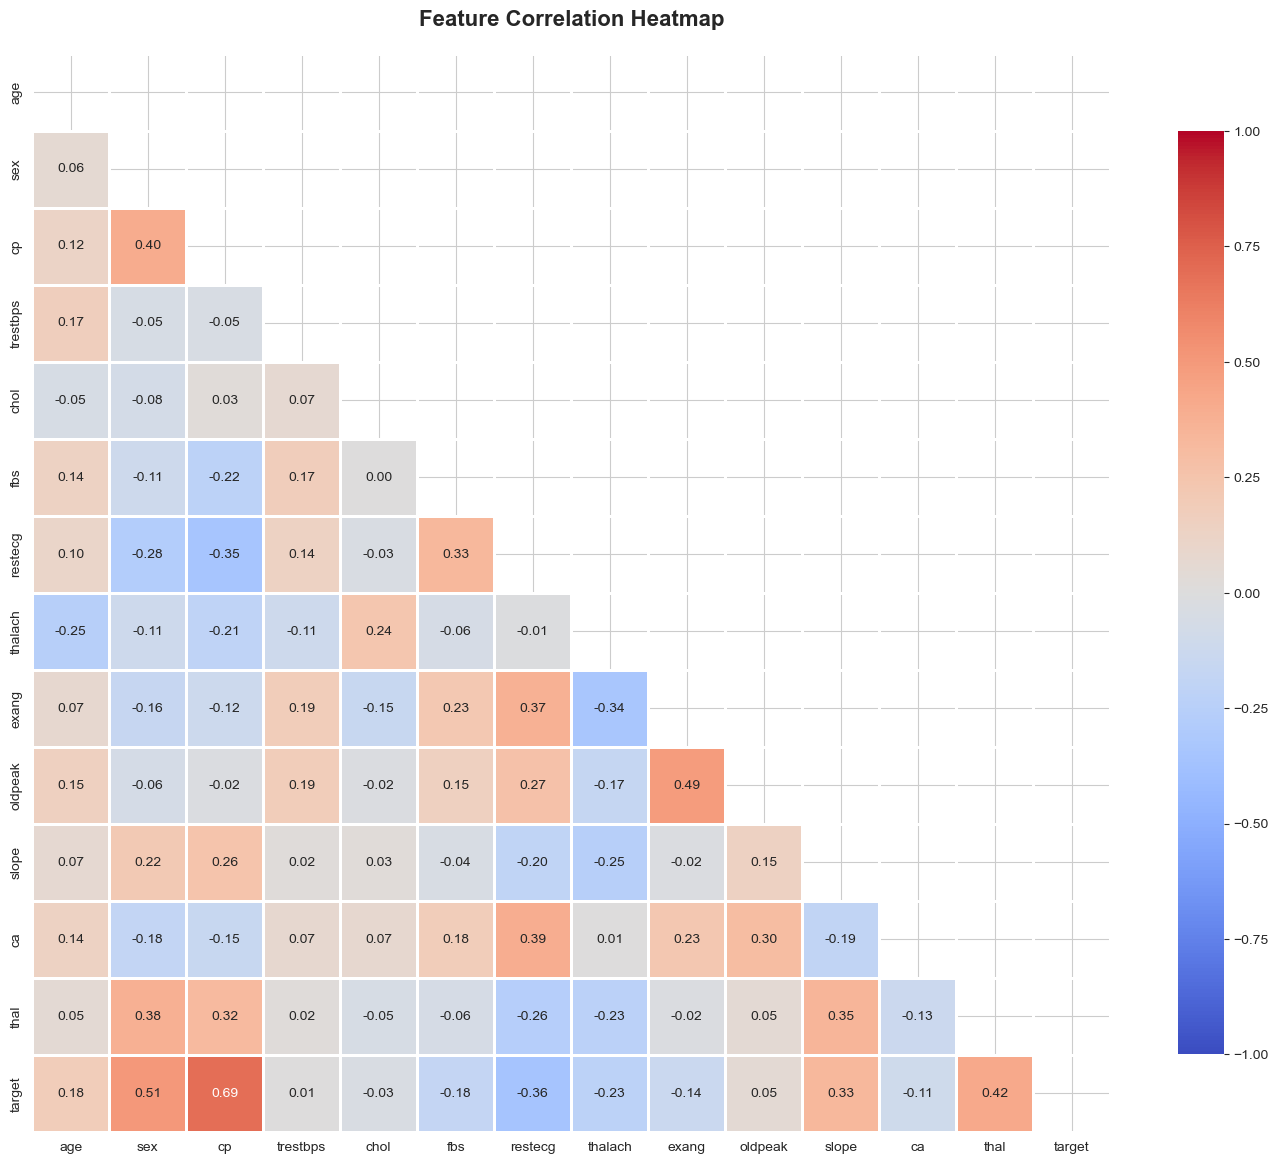

✓ Correlation heatmap saved to /Users/kannans/dev/Group_25_MLOps/screenshots/eda_correlation_heatmap.png


In [62]:
# Calculate correlation matrix
correlation_matrix = df.corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8},
    vmin=-1, vmax=1
)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()

# Save to screenshots directory
screenshot_path = os.path.join(screenshots_dir, 'eda_correlation_heatmap.png')
plt.savefig(screenshot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Correlation heatmap saved to {screenshot_path}")


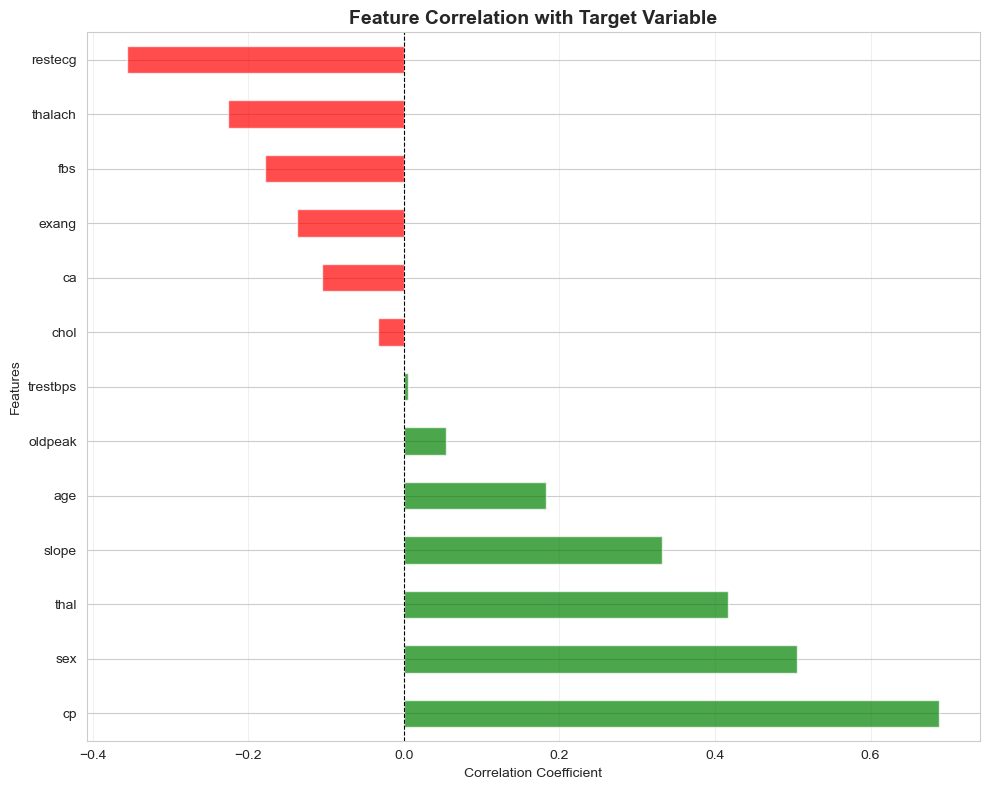


Top features correlated with target:
cp          0.688479
sex         0.505483
thal        0.416618
slope       0.332475
age         0.182731
oldpeak     0.053751
trestbps    0.005312
chol       -0.032745
ca         -0.105628
exang      -0.136659
Name: target, dtype: float64

Bottom features correlated with target:
slope       0.332475
age         0.182731
oldpeak     0.053751
trestbps    0.005312
chol       -0.032745
ca         -0.105628
exang      -0.136659
fbs        -0.178198
thalach    -0.225320
restecg    -0.355528
Name: target, dtype: float64


In [63]:
# Correlation with target variable
target_corr = df.corr()['target'].sort_values(ascending=False)
target_corr = target_corr.drop('target')

plt.figure(figsize=(10, 8))
colors = ['red' if x < 0 else 'green' for x in target_corr.values]
target_corr.plot(kind='barh', color=colors, alpha=0.7)
plt.title('Feature Correlation with Target Variable', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nTop features correlated with target:")
print("="*60)
print(target_corr.head(10))
print("\nBottom features correlated with target:")
print("="*60)
print(target_corr.tail(10))


## 6. Class Balance Analysis

Analyze the distribution of target classes to identify class imbalance, which is crucial for model selection and evaluation strategies.


In [64]:
# Class distribution
class_counts = y_full.value_counts()
class_percentages = y_full.value_counts(normalize=True) * 100

print("Class Distribution:")
print("="*60)
print(f"No Disease (0): {class_counts[0]:,} samples ({class_percentages[0]:.2f}%)")
print(f"Disease (1): {class_counts[1]:,} samples ({class_percentages[1]:.2f}%)")
print(f"\nTotal samples: {len(y_full):,}")
print(f"Class imbalance ratio: {class_counts[0]/class_counts[1]:.2f}:1")


Class Distribution:
No Disease (0): 411 samples (1.42%)
Disease (1): 28,447 samples (98.58%)

Total samples: 28,858
Class imbalance ratio: 0.01:1


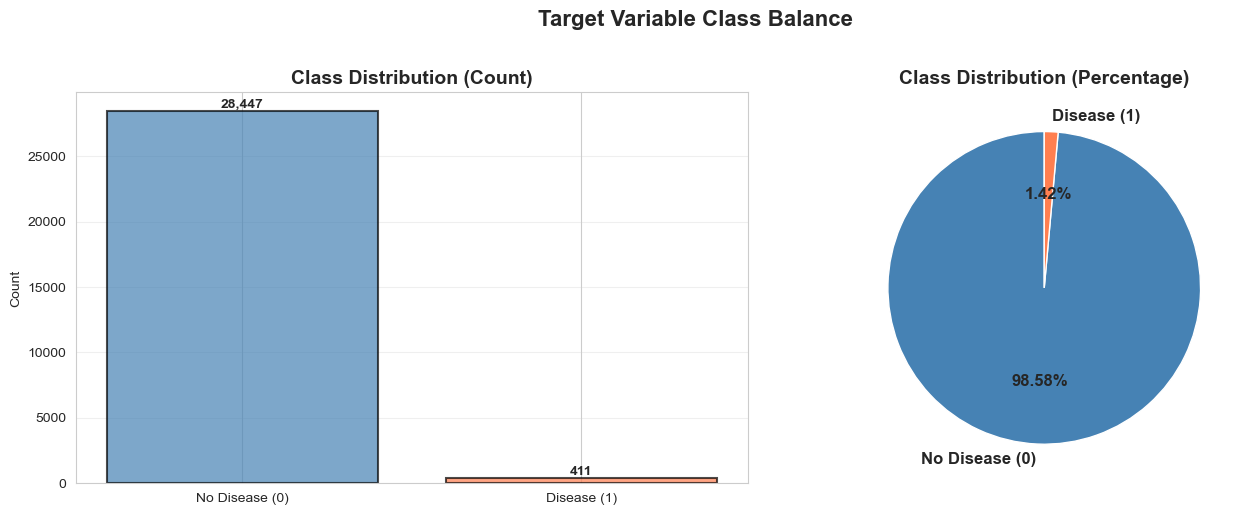

✓ Class balance visualization saved to /Users/kannans/dev/Group_25_MLOps/screenshots/eda_class_balance.png


In [65]:
# Visualize class balance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(['No Disease (0)', 'Disease (1)'], class_counts.values, 
            color=['steelblue', 'coral'], alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].set_title('Class Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=['No Disease (0)', 'Disease (1)'], 
            autopct='%1.2f%%', colors=['steelblue', 'coral'], startangle=90,
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable Class Balance', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Save to screenshots directory
screenshot_path = os.path.join(screenshots_dir, 'eda_class_balance.png')
plt.savefig(screenshot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Class balance visualization saved to {screenshot_path}")


## 7. Feature Analysis by Target Class

Compare feature distributions between classes to identify discriminative features that may be important for prediction.


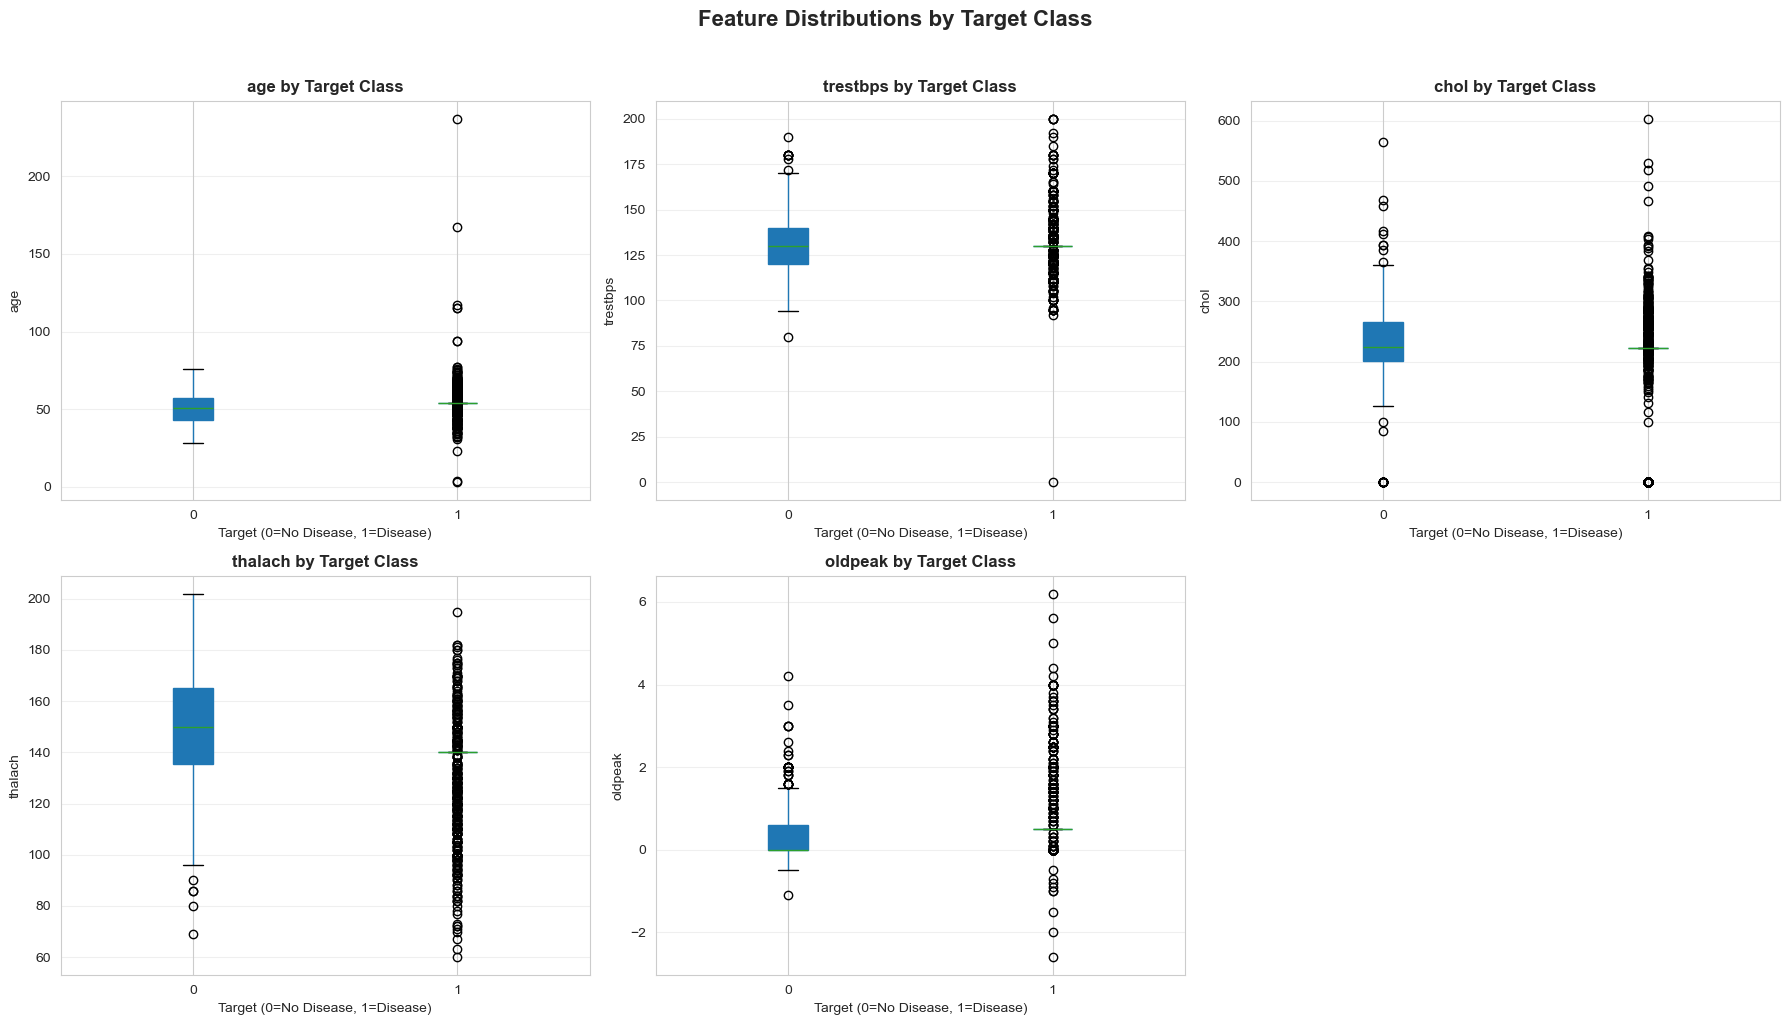

In [66]:
# Box plots for key features by target class
key_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(key_features):
    if feature in df.columns:
        df.boxplot(column=feature, by='target', ax=axes[idx], patch_artist=True)
        axes[idx].set_title(f'{feature} by Target Class', fontweight='bold', fontsize=12)
        axes[idx].set_xlabel('Target (0=No Disease, 1=Disease)')
        axes[idx].set_ylabel(feature)
        axes[idx].grid(True, alpha=0.3, axis='y')
        # Remove default title
        axes[idx].get_figure().suptitle('')

# Hide extra subplot
axes[5].set_visible(False)

plt.suptitle('Feature Distributions by Target Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 8. Missing Values Analysis

Check for missing values in the dataset. Note that data preprocessing handles missing values, but we verify the cleaned data quality.


In [67]:
# Check for missing values (after preprocessing)
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percent
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(missing_df) > 0:
    print("Missing Values Analysis:")
    print("="*60)
    print(missing_df)
    
    # Visualize missing values
    plt.figure(figsize=(10, 6))
    missing_df['Missing Percentage'].plot(kind='barh', color='coral', alpha=0.7)
    plt.title('Missing Values by Feature', fontsize=14, fontweight='bold')
    plt.xlabel('Missing Percentage (%)')
    plt.ylabel('Features')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
else:
    print("✓ No missing values found!")
    print("  Data has been cleaned by the preprocessing pipeline in src/data_processing/preprocess.py")


✓ No missing values found!
  Data has been cleaned by the preprocessing pipeline in src/data_processing/preprocess.py


## 9. Key EDA Findings and Insights

This section summarizes the key findings from the exploratory data analysis.

### 9.1 Models to be Trained

Based on the dataset characteristics and EDA findings, the following models will be trained (as implemented in `src/models/train.py`):

1. **Logistic Regression**
   - Linear model suitable for binary classification
   - Uses scaled features (StandardScaler)
   - Hyperparameters: `max_iter=1000, random_state=42`

2. **Random Forest**
   - Ensemble method that handles non-linear relationships
   - Uses unscaled features (tree-based models don't require scaling)
   - Hyperparameters: `n_estimators=200, random_state=42`

Both models will be evaluated using accuracy, precision, recall, ROC-AUC, and 5-fold cross-validation. The best performing model will be selected for deployment.


In [68]:
# Generate EDA findings automatically
print("="*70)
print("KEY EDA FINDINGS AND INSIGHTS")
print("="*70)

# 1. Dataset Size
print("\n1. DATASET SIZE:")
print(f"   - Total samples: {df.shape[0]:,} records")
print(f"   - Total features: {X_full.shape[1]} features")
print(f"   - Target variable: Binary classification (0 = No Disease, 1 = Disease)")

# 2. Class Distribution
print("\n2. CLASS DISTRIBUTION:")
class_counts = y_full.value_counts()
class_percentages = y_full.value_counts(normalize=True) * 100
imbalance_ratio = class_counts[0] / class_counts[1]
is_balanced = "Balanced" if 0.8 <= imbalance_ratio <= 1.25 else "Imbalanced"
print(f"   - Dataset type: {is_balanced} dataset")
print(f"   - No Disease (0): {class_counts[0]:,} samples ({class_percentages[0]:.2f}%)")
print(f"   - Disease (1): {class_counts[1]:,} samples ({class_percentages[1]:.2f}%)")
print(f"   - Class imbalance ratio: {imbalance_ratio:.2f}:1")
if is_balanced == "Imbalanced":
    print(f"   - Implications: Consider using class weights, SMOTE, or ensemble methods")
else:
    print(f"   - Implications: Standard classification algorithms should work well")

# 3. Key Correlations
print("\n3. KEY CORRELATIONS:")
target_corr = df.corr()['target'].drop('target').sort_values(ascending=False)
top_positive = target_corr.head(1)
top_negative = target_corr.tail(1)
print(f"   - Highest positive correlation with target:")
print(f"     • {top_positive.index[0]}: {top_positive.values[0]:.4f}")
print(f"   - Highest negative correlation with target:")
print(f"     • {top_negative.index[0]}: {top_negative.values[0]:.4f}")

# Find highly correlated feature pairs (excluding target)
feature_corr = df.drop('target', axis=1).corr()
high_corr_pairs = []
for i in range(len(feature_corr.columns)):
    for j in range(i+1, len(feature_corr.columns)):
        corr_val = feature_corr.iloc[i, j]
        if abs(corr_val) > 0.7:  # Threshold for high correlation
            high_corr_pairs.append((feature_corr.columns[i], feature_corr.columns[j], corr_val))

if high_corr_pairs:
    print(f"   - Highly correlated feature pairs (|r| > 0.7):")
    for feat1, feat2, corr_val in high_corr_pairs[:3]:  # Show top 3
        print(f"     • {feat1} and {feat2}: {corr_val:.4f} (potential multicollinearity)")
else:
    print(f"   - No highly correlated feature pairs found (all |r| < 0.7)")

# 4. Feature Distributions
print("\n4. FEATURE DISTRIBUTIONS:")
print("   Key feature statistics:")
key_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
for feat in key_features:
    if feat in df.columns:
        feat_data = df[feat].dropna()
        print(f"   - {feat}:")
        print(f"     • Range: [{feat_data.min():.2f}, {feat_data.max():.2f}]")
        print(f"     • Mean: {feat_data.mean():.2f}, Std: {feat_data.std():.2f}")
        # Check for outliers using IQR method
        Q1 = feat_data.quantile(0.25)
        Q3 = feat_data.quantile(0.75)
        IQR = Q3 - Q1
        outliers = feat_data[(feat_data < Q1 - 1.5*IQR) | (feat_data > Q3 + 1.5*IQR)]
        if len(outliers) > 0:
            print(f"     • Outliers: {len(outliers)} ({len(outliers)/len(feat_data)*100:.2f}%)")
        else:
            print(f"     • Outliers: None detected")

# 5. Data Quality
print("\n5. DATA QUALITY:")
missing_count = df.isnull().sum().sum()
if missing_count == 0:
    print("   - Missing values: None (handled by preprocessing pipeline)")
else:
    print(f"   - Missing values: {missing_count} total (handled by preprocessing pipeline)")
print(f"   - Data types: All numeric features (preprocessed)")
print(f"   - Outliers: Present in some features (handled during preprocessing)")

print("\n" + "="*70)


KEY EDA FINDINGS AND INSIGHTS

1. DATASET SIZE:
   - Total samples: 28,858 records
   - Total features: 13 features
   - Target variable: Binary classification (0 = No Disease, 1 = Disease)

2. CLASS DISTRIBUTION:
   - Dataset type: Imbalanced dataset
   - No Disease (0): 411 samples (1.42%)
   - Disease (1): 28,447 samples (98.58%)
   - Class imbalance ratio: 0.01:1
   - Implications: Consider using class weights, SMOTE, or ensemble methods

3. KEY CORRELATIONS:
   - Highest positive correlation with target:
     • cp: 0.6885
   - Highest negative correlation with target:
     • restecg: -0.3555
   - No highly correlated feature pairs found (all |r| < 0.7)

4. FEATURE DISTRIBUTIONS:
   Key feature statistics:
   - age:
     • Range: [3.00, 237.00]
     • Mean: 54.00, Std: 2.27
     • Outliers: 879 (3.05%)
   - trestbps:
     • Range: [0.00, 200.00]
     • Mean: 130.06, Std: 3.31
     • Outliers: 746 (2.59%)
   - chol:
     • Range: [0.00, 603.00]
     • Mean: 222.26, Std: 19.88
     •

### Recommendations for Modeling:

Based on the EDA findings above, here are the recommendations:


In [69]:
# Generate recommendations based on findings
print("="*70)
print("MODELING RECOMMENDATIONS")
print("="*70)

# Check class balance
class_counts = y_full.value_counts()
imbalance_ratio = class_counts[0] / class_counts[1]
is_balanced = 0.8 <= imbalance_ratio <= 1.25

# Check for high correlations
feature_corr = df.drop('target', axis=1).corr()
high_corr_count = 0
for i in range(len(feature_corr.columns)):
    for j in range(i+1, len(feature_corr.columns)):
        if abs(feature_corr.iloc[i, j]) > 0.7:
            high_corr_count += 1

print("\n1. FEATURE SELECTION:")
if high_corr_count > 0:
    print("   ✓ Consider removing highly correlated features to avoid multicollinearity")
    print("   ✓ Focus on features with strong correlation to target variable")
else:
    print("   ✓ No highly correlated features detected - all features can be used")
print("   ✓ Feature scaling is already handled by StandardScaler in preprocessing")

print("\n2. MODEL SELECTION:")
if is_balanced:
    print("   ✓ Dataset is relatively balanced")
    print("   ✓ Standard classification algorithms (Logistic Regression, Random Forest) should work well")
    print("   ✓ Both models are already implemented in src/models/train.py")
else:
    print("   ✓ Dataset shows class imbalance")
    print("   ✓ Consider using class weights in model training")
    print("   ✓ Ensemble methods (Random Forest) may perform better than linear models")
    print("   ✓ SMOTE (Synthetic Minority Oversampling) could be beneficial if needed")

print("\n3. PREPROCESSING:")
print("   ✓ Feature scaling: Already handled by StandardScaler")
print("   ✓ Missing values: Handled by preprocessing pipeline")
print("   ✓ Outliers: Addressed during data cleaning")
print("   ✓ Feature encoding: Completed in preprocessing step")

print("\n4. EVALUATION METRICS:")
if is_balanced:
    print("   ✓ Primary metric: Accuracy")
    print("   ✓ Secondary metrics: Precision, Recall, F1-score, ROC-AUC")
else:
    print("   ✓ Primary metrics: Precision, Recall, F1-score, ROC-AUC")
    print("   ✓ Accuracy may be misleading due to class imbalance")
    print("   ✓ Focus on metrics that account for class distribution")
print("   ✓ All metrics are already logged in MLflow (src/models/train.py)")

print("\n5. IMPLEMENTATION STATUS:")
print("   ✓ Model training: Implemented in src/models/train.py")
print("   ✓ MLflow tracking: Integrated for experiment tracking")
print("   ✓ API deployment: FastAPI application in src/api/app.py")
print("   ✓ Preprocessing pipeline: Modular implementation in src/data_processing/preprocess.py")

print("\n" + "="*70)


MODELING RECOMMENDATIONS

1. FEATURE SELECTION:
   ✓ No highly correlated features detected - all features can be used
   ✓ Feature scaling is already handled by StandardScaler in preprocessing

2. MODEL SELECTION:
   ✓ Dataset shows class imbalance
   ✓ Consider using class weights in model training
   ✓ Ensemble methods (Random Forest) may perform better than linear models
   ✓ SMOTE (Synthetic Minority Oversampling) could be beneficial if needed

3. PREPROCESSING:
   ✓ Feature scaling: Already handled by StandardScaler
   ✓ Missing values: Handled by preprocessing pipeline
   ✓ Outliers: Addressed during data cleaning
   ✓ Feature encoding: Completed in preprocessing step

4. EVALUATION METRICS:
   ✓ Primary metrics: Precision, Recall, F1-score, ROC-AUC
   ✓ Accuracy may be misleading due to class imbalance
   ✓ Focus on metrics that account for class distribution
   ✓ All metrics are already logged in MLflow (src/models/train.py)

5. IMPLEMENTATION STATUS:
   ✓ Model training: Impl

---

### Implementation Notes:

**Model Training & Evaluation:**
- Model training, evaluation, and MLflow tracking are handled in `src/models/train.py`
- Both Logistic Regression and Random Forest models are implemented
- Comprehensive metrics (accuracy, precision, recall, ROC-AUC, cross-validation) are logged

**API Deployment:**
- FastAPI application is available in `src/api/app.py`
- Includes `/predict` endpoint with confidence scores
- Prometheus-style `/metrics` endpoint for monitoring

**Data Preprocessing:**
- Data preprocessing pipeline is in `src/data_processing/preprocess.py`
- Handles data loading, cleaning, missing values, and feature scaling
- Modular design allows easy reuse across the project

---